# 03. Baseline Modeling

이 노트북은 `02_feature_engineering.ipynb`에서 만든 v1 feature dataset을 기준으로 첫 번째 RMSLE baseline을 측정합니다.

목표는 최고 성능 모델을 바로 찾는 것이 아니라, 이후 모델링 노트북에서 개선폭을 판단할 기준선을 만드는 것입니다.

- `data/proceed/train_fe_v1.csv` 로드
- RMSLE metric 구현
- `Rings` 분포를 고려한 stratified KFold 구성
- 단순 모델과 트리 기반 baseline 비교
- 원본 타깃 학습과 `log1p(Rings)` 타깃 변환 비교
- best baseline의 OOF prediction 오류 패턴 확인


In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_SPLITS = 5

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCEED_DIR = PROJECT_ROOT / "data" / "proceed"
TRAIN_PATH = PROCEED_DIR / "train_fe_v1.csv"
TEST_PATH = PROCEED_DIR / "test_fe_v1.csv"

ID_COL = "id"
TARGET = "Rings"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.6f}".format)
sns.set_theme(style="whitegrid", context="notebook")


## 1. Load v1 Feature Dataset

Baseline은 raw CSV를 직접 가공하지 않고, 고정된 v1 feature dataset만 사용합니다. 이렇게 해야 이후 feature version과 모델 version을 명확하게 비교할 수 있습니다.


In [2]:
assert TRAIN_PATH.exists(), f"Missing feature file: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Missing feature file: {TEST_PATH}"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
X = train[feature_cols]
y = train[TARGET]
X_test = test[feature_cols]

print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"features: {len(feature_cols)}")

display(train.head())
display(pd.Series(feature_cols, name="feature"))


train: (90615, 19)
test : (60411, 18)
features: 17


,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Height_is_zero,Volume,Density,Shucked_ratio,Viscera_ratio,Shell_ratio,Shell_to_shucked,Sex_F,Sex_I,Sex_M,Rings
0,0,0.550000,0.430000,0.150000,0.771500,0.328500,0.146500,0.240000,0,0.035475,21.747710,0.425794,0.189890,0.311082,0.730594,1,0,0,11
1,1,0.630000,0.490000,0.145000,1.130000,0.458000,0.276500,0.320000,0,0.044761,25.244909,0.405310,0.244690,0.283186,0.698690,1,0,0,11
2,2,0.160000,0.110000,0.025000,0.021000,0.005500,0.003000,0.005000,0,0.000440,47.727273,0.261905,0.142857,0.238095,0.909091,0,1,0,6
3,3,0.595000,0.475000,0.150000,0.914500,0.375500,0.205500,0.250000,0,0.042394,21.571576,0.410607,0.224713,0.273373,0.665779,0,0,1,10
4,4,0.555000,0.425000,0.130000,0.782000,0.369500,0.160000,0.197500,0,0.030664,25.502426,0.472506,0.204604,0.252558,0.534506,0,1,0,9


0               Length
1             Diameter
2               Height
3         Whole_weight
4       Shucked_weight
5       Viscera_weight
6         Shell_weight
7       Height_is_zero
8               Volume
9              Density
10       Shucked_ratio
11       Viscera_ratio
12         Shell_ratio
13    Shell_to_shucked
14               Sex_F
15               Sex_I
16               Sex_M
Name: feature, dtype: str

## 2. Input Validation

모델 학습 전에 train/test feature schema, 결측, 무한대, 타깃 범위를 확인합니다.


In [3]:
def validate_model_inputs(train_df: pd.DataFrame, test_df: pd.DataFrame, features: list[str]) -> None:
    assert ID_COL in train_df.columns and ID_COL in test_df.columns, "id column is required."
    assert TARGET in train_df.columns, "target column is required in train."
    assert TARGET not in test_df.columns, "target column should not exist in test."
    assert train_df[ID_COL].is_unique and test_df[ID_COL].is_unique, "id must be unique."
    assert features == [c for c in test_df.columns if c != ID_COL], "train/test feature schema differs."
    assert train_df[features + [TARGET]].isna().sum().sum() == 0, "train has missing values."
    assert test_df[features].isna().sum().sum() == 0, "test has missing values."
    assert np.isfinite(train_df[features + [TARGET]].to_numpy()).all(), "train has non-finite values."
    assert np.isfinite(test_df[features].to_numpy()).all(), "test has non-finite values."
    assert (train_df[TARGET] >= 0).all(), "RMSLE requires non-negative target."

validate_model_inputs(train, test, feature_cols)

input_summary = pd.DataFrame(
    {
        "train": [len(train), train.shape[1], train[feature_cols].isna().sum().sum(), y.min(), y.mean(), y.max()],
        "test": [len(test), test.shape[1], test[feature_cols].isna().sum().sum(), np.nan, np.nan, np.nan],
    },
    index=["rows", "columns", "missing_feature_cells", "target_min", "target_mean", "target_max"],
)

display(input_summary)


,train,test
rows,90615.000000,60411.000000
columns,19.000000,18.000000
missing_feature_cells,0.000000,0.000000
target_min,1.000000,NaN
target_mean,9.696794,NaN
target_max,29.000000,NaN


## 3. Metric and Validation Split

Kaggle metric은 RMSLE입니다. 예측값이 0보다 작으면 log 계산이 불가능하므로 평가 전에 0 이상으로 clipping합니다.

`Rings`는 불균형한 정수형 타깃이므로, `qcut`으로 타깃 구간을 만든 뒤 `StratifiedKFold`를 사용합니다.


In [4]:
def rmsle(y_true: np.ndarray | pd.Series, y_pred: np.ndarray | pd.Series) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


def make_stratification_bins(target: pd.Series, q: int = 10) -> pd.Series:
    bins = pd.qcut(target, q=q, labels=False, duplicates="drop")
    return bins.astype(int)

y_bins = make_stratification_bins(y)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_distribution = pd.crosstab(
    pd.Series(np.fromiter((fold for fold, (_, valid_idx) in enumerate(cv.split(X, y_bins), start=1) for _ in valid_idx), dtype=int), name="fold"),
    y.iloc[np.concatenate([valid_idx for _, valid_idx in cv.split(X, y_bins)])].rename("Rings"),
    normalize="index",
)

print(f"RMSLE sanity check, constant median prediction: {rmsle(y, np.full_like(y, y.median(), dtype=float)):.6f}")
display(y_bins.value_counts(normalize=True).sort_index().rename("bin_ratio"))
display(fold_distribution.round(4))


RMSLE sanity check, constant median prediction: 0.286740


Rings
0   0.111626
1   0.099410
2   0.160007
3   0.192739
4   0.137549
5   0.144855
6   0.072626
7   0.081190
Name: bin_ratio, dtype: float64

Rings,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,29
fold,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.000200,0.000300,0.003600,0.016100,0.033100,0.061300,0.101300,0.160700,0.190900,0.140900,0.092600,0.049400,0.042000,0.026300,0.021700,0.015600,0.013300,0.010000,0.007300,0.006300,0.002300,0.001000,0.002400,0.000200,0.000300,0.000100,0.000500,0.000200
2,0.000400,0.000400,0.004100,0.015100,0.031500,0.059900,0.096300,0.157900,0.193200,0.139400,0.092300,0.052800,0.044300,0.026800,0.024800,0.017000,0.013900,0.008400,0.007200,0.005600,0.003300,0.001400,0.001900,0.000600,0.000500,0.000400,0.000400,0.000300
3,0.000300,0.000300,0.004200,0.015800,0.030200,0.060600,0.099300,0.159900,0.194400,0.135700,0.090800,0.051900,0.046200,0.028900,0.023100,0.016400,0.012900,0.008600,0.007000,0.005800,0.003400,0.001000,0.001900,0.000400,0.000100,0.000100,0.000400,0.000400
4,0.000300,0.000200,0.004900,0.015500,0.031900,0.057200,0.102500,0.159200,0.191600,0.138200,0.093800,0.054000,0.046600,0.026600,0.022100,0.015200,0.011800,0.009500,0.006900,0.005200,0.002700,0.001300,0.002000,0.000200,0.000100,0.000100,0.000200,0.000100
5,0.000100,0.000300,0.004400,0.014800,0.031200,0.059500,0.097800,0.162400,0.193500,0.133600,0.094400,0.052200,0.045700,0.029700,0.022700,0.015200,0.013000,0.010200,0.006900,0.005100,0.002500,0.001300,0.001700,0.000300,0.000200,0.000300,0.000700,0.000200


## 4. Baseline Model Candidates

비교 대상은 해석 가능한 선형 모델과 기본 트리 계열 모델입니다. `log1p` 타깃 변환은 RMSLE와 잘 맞는 경우가 많아서 Ridge와 HistGradientBoosting에 함께 비교합니다.


In [5]:
def make_hgbr(random_state: int = RANDOM_STATE) -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_iter=350,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.01,
        early_stopping=True,
        random_state=random_state,
    )

models = {
    "Dummy_median": DummyRegressor(strategy="median"),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "Ridge_log_target": TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=16,
        min_samples_leaf=5,
        max_features=0.85,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": make_hgbr(),
    "HistGradientBoosting_log_target": TransformedTargetRegressor(
        regressor=make_hgbr(),
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
}

pd.Series(models.keys(), name="model")


0                       Dummy_median
1                              Ridge
2                   Ridge_log_target
3                       RandomForest
4               HistGradientBoosting
5    HistGradientBoosting_log_target
Name: model, dtype: str

## 5. Cross-Validation

각 모델을 동일한 fold로 평가합니다. 아래 결과의 `rmsle_mean`이 이후 모델링의 기준선입니다.


In [6]:
def cross_validate_model(model_name: str, estimator, X_data: pd.DataFrame, y_data: pd.Series, splitter, stratify_bins: pd.Series):
    rows = []
    oof_pred = np.zeros(len(y_data), dtype=float)

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X_data, stratify_bins), start=1):
        X_train, X_valid = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_train, y_valid = y_data.iloc[train_idx], y_data.iloc[valid_idx]

        model = clone(estimator)
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = perf_counter() - start

        pred = np.clip(model.predict(X_valid), 0, None)
        score = rmsle(y_valid, pred)
        oof_pred[valid_idx] = pred

        rows.append(
            {
                "model": model_name,
                "fold": fold,
                "rmsle": score,
                "fit_seconds": fit_seconds,
                "prediction_min": pred.min(),
                "prediction_mean": pred.mean(),
                "prediction_max": pred.max(),
            }
        )
        print(f"{model_name:32s} fold {fold}: RMSLE={score:.6f}, fit={fit_seconds:.1f}s")

    return rows, oof_pred

cv_rows = []
oof_predictions = {}

for model_name, estimator in models.items():
    rows, oof_pred = cross_validate_model(model_name, estimator, X, y, cv, y_bins)
    cv_rows.extend(rows)
    oof_predictions[model_name] = oof_pred

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results
    .groupby("model", as_index=False)
    .agg(
        rmsle_mean=("rmsle", "mean"),
        rmsle_std=("rmsle", "std"),
        fit_seconds_total=("fit_seconds", "sum"),
        pred_min=("prediction_min", "min"),
        pred_mean=("prediction_mean", "mean"),
        pred_max=("prediction_max", "max"),
    )
    .sort_values("rmsle_mean")
    .reset_index(drop=True)
)

best_model_name = cv_summary.loc[0, "model"]
best_oof_pred = oof_predictions[best_model_name]
best_oof_rmsle = rmsle(y, best_oof_pred)

print("\nCV summary")
print(cv_summary.to_string(index=False))
print(f"\nBest model: {best_model_name}")
print(f"Best OOF RMSLE: {best_oof_rmsle:.6f}")

display(cv_results)
display(cv_summary)


Dummy_median                     fold 1: RMSLE=0.285110, fit=0.0s
Dummy_median                     fold 2: RMSLE=0.286171, fit=0.0s
Dummy_median                     fold 3: RMSLE=0.287111, fit=0.0s
Dummy_median                     fold 4: RMSLE=0.286711, fit=0.0s
Dummy_median                     fold 5: RMSLE=0.288588, fit=0.0s


Ridge                            fold 1: RMSLE=0.159437, fit=0.1s


Ridge                            fold 2: RMSLE=0.159088, fit=0.0s
Ridge                            fold 3: RMSLE=0.159505, fit=0.0s
Ridge                            fold 4: RMSLE=0.158848, fit=0.0s


Ridge                            fold 5: RMSLE=0.163074, fit=0.0s


Ridge_log_target                 fold 1: RMSLE=0.158254, fit=0.0s
Ridge_log_target                 fold 2: RMSLE=0.157363, fit=0.0s


...

HistGradientBoosting_log_target  fold 3: RMSLE=0.150157, fit=0.8s


HistGradientBoosting_log_target  fold 4: RMSLE=0.149752, fit=0.7s


HistGradientBoosting_log_target  fold 5: RMSLE=0.151296, fit=0.9s

CV summary
                          model  rmsle_mean  rmsle_std  fit_seconds_total  pred_min  pred_mean   pred_max
HistGradientBoosting_log_target    0.149917   0.000889           4.519269  3.598721   9.563321  19.746096
           HistGradientBoosting    0.150623   0.000923           4.370076  4.075557   9.695512  20.702031
                   RandomForest    0.151209   0.000756          39.721134  3.359290   9.707902  20.289515
               Ridge_log_target    0.158517   0.001720           0.195623  2.474280   9.554201 102.861157
                          Ridge    0.159990   0.001744           0.200536  0.000000   9.697120  35.087093
                   Dummy_median    0.286738   0.001278           0.005841  9.000000   9.000000   9.000000

Best model: HistGradientBoosting_log_target
Best OOF RMSLE: 0.149919


,model,fold,rmsle,fit_seconds,prediction_min,prediction_mean,prediction_max
0,Dummy_median,1,0.285110,0.001333,9.000000,9.000000,9.000000
1,Dummy_median,2,0.286171,0.001566,9.000000,9.000000,9.000000
2,Dummy_median,3,0.287111,0.001163,9.000000,9.000000,9.000000
3,Dummy_median,4,0.286711,0.000919,9.000000,9.000000,9.000000
4,Dummy_median,5,0.288588,0.000861,9.000000,9.000000,9.000000
5,Ridge,1,0.159437,0.050517,2.740970,9.700780,27.114278
6,Ridge,2,0.159088,0.039812,2.737731,9.683626,27.589840
7,Ridge,3,0.159505,0.036862,1.556358,9.693715,23.355040
8,Ridge,4,0.158848,0.036503,2.091679,9.699560,27.853293
9,Ridge,5,0.163074,0.036842,0.000000,9.707918,35.087093


,model,rmsle_mean,rmsle_std,fit_seconds_total,pred_min,pred_mean,pred_max
0,HistGradientBoosting_log_target,0.149917,0.000889,4.519269,3.598721,9.563321,19.746096
1,HistGradientBoosting,0.150623,0.000923,4.370076,4.075557,9.695512,20.702031
2,RandomForest,0.151209,0.000756,39.721134,3.359290,9.707902,20.289515
3,Ridge_log_target,0.158517,0.001720,0.195623,2.474280,9.554201,102.861157
4,Ridge,0.159990,0.001744,0.200536,0.000000,9.697120,35.087093
5,Dummy_median,0.286738,0.001278,0.005841,9.000000,9.000000,9.000000


## 6. Result Visualization

모델별 평균 RMSLE와 fold 편차를 확인합니다. Dummy 대비 어느 정도 개선되었는지도 함께 봅니다.


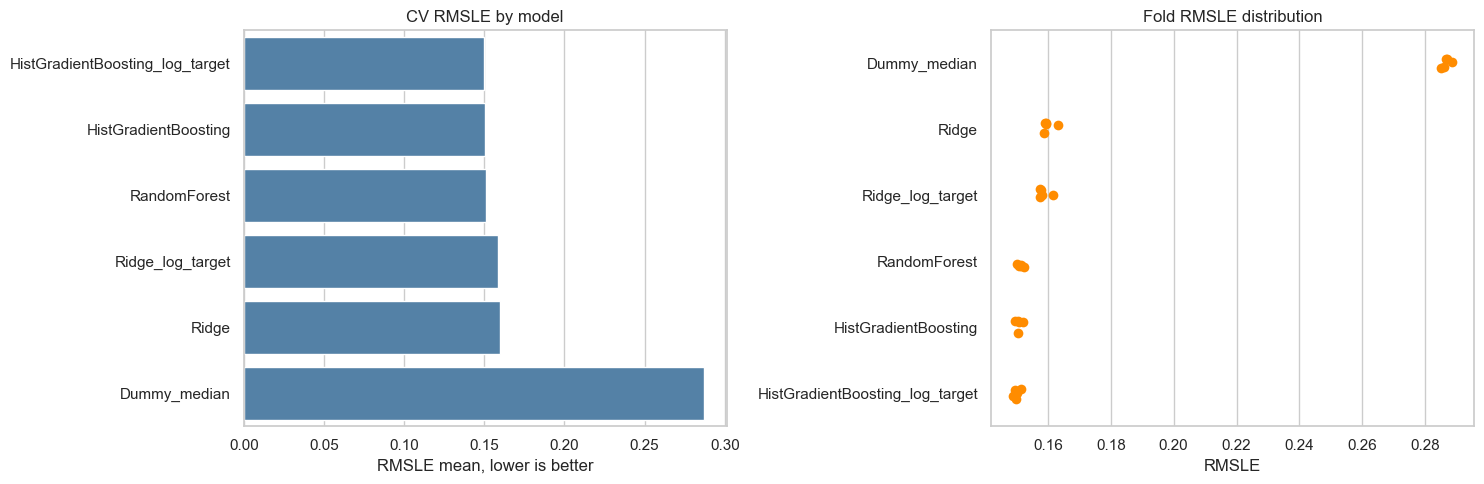

,model,rmsle_mean,rmsle_std,fit_seconds_total,pred_min,pred_mean,pred_max,improvement_vs_dummy
0,HistGradientBoosting_log_target,0.149917,0.000889,4.519269,3.598721,9.563321,19.746096,0.136822
1,HistGradientBoosting,0.150623,0.000923,4.370076,4.075557,9.695512,20.702031,0.136115
2,RandomForest,0.151209,0.000756,39.721134,3.359290,9.707902,20.289515,0.135529
3,Ridge_log_target,0.158517,0.001720,0.195623,2.474280,9.554201,102.861157,0.128221
4,Ridge,0.159990,0.001744,0.200536,0.000000,9.697120,35.087093,0.126748
5,Dummy_median,0.286738,0.001278,0.005841,9.000000,9.000000,9.000000,0.000000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=cv_summary, y="model", x="rmsle_mean", ax=axes[0], color="steelblue")
axes[0].set_title("CV RMSLE by model")
axes[0].set_xlabel("RMSLE mean, lower is better")
axes[0].set_ylabel("")

sns.stripplot(data=cv_results, y="model", x="rmsle", ax=axes[1], color="darkorange", size=7)
axes[1].set_title("Fold RMSLE distribution")
axes[1].set_xlabel("RMSLE")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

baseline_score = cv_summary.loc[cv_summary["model"].eq("Dummy_median"), "rmsle_mean"].iloc[0]
cv_summary.assign(improvement_vs_dummy=baseline_score - cv_summary["rmsle_mean"])


## 7. Best Baseline OOF Diagnostics

가장 좋은 baseline의 out-of-fold prediction을 기준으로, 어떤 `Rings` 구간에서 오차가 커지는지 확인합니다.


In [8]:
oof_df = pd.DataFrame(
    {
        "id": train[ID_COL],
        "Rings": y,
        "prediction": best_oof_pred,
    }
)
oof_df["residual"] = oof_df["prediction"] - oof_df["Rings"]
oof_df["abs_error"] = oof_df["residual"].abs()

oof_by_ring_rows = []
for ring, group in oof_df.groupby("Rings"):
    oof_by_ring_rows.append(
        {
            "Rings": ring,
            "count": len(group),
            "prediction_mean": group["prediction"].mean(),
            "residual_mean": group["residual"].mean(),
            "abs_error_mean": group["abs_error"].mean(),
            "rmsle": rmsle(group["Rings"], group["prediction"]),
        }
    )

oof_by_ring = pd.DataFrame(oof_by_ring_rows)

print(f"Best model: {best_model_name}")
print(f"OOF RMSLE: {best_oof_rmsle:.6f}")
display(oof_df.describe().T)
display(oof_by_ring)


Best model: HistGradientBoosting_log_target
OOF RMSLE: 0.149919


,count,mean,std,min,25%,50%,75%,max
id,90615.000000,45307.000000,26158.441658,0.000000,22653.500000,45307.000000,67960.500000,90614.000000
Rings,90615.000000,9.696794,3.176221,1.000000,8.000000,9.000000,11.000000,29.000000
prediction,90615.000000,9.563321,2.499968,3.598721,7.922642,9.395101,10.964880,19.746096
residual,90615.000000,-0.133474,1.850293,-19.990824,-0.753701,0.131145,0.862384,10.549123
abs_error,90615.000000,1.226698,1.391616,0.000009,0.367411,0.816905,1.540043,19.990824


,Rings,count,prediction_mean,residual_mean,abs_error_mean,rmsle
0,1,25,8.834615,7.834615,7.834615,1.587921
1,2,29,6.851296,4.851296,4.851296,0.962486
2,3,386,4.699592,1.699592,1.699592,0.364902
3,4,1402,4.587680,0.587680,0.592344,0.139477
4,5,2862,5.379714,0.379714,0.659262,0.126192
5,6,5411,6.501666,0.501666,0.787469,0.129732
6,7,9008,7.332922,0.332922,0.692172,0.110888
7,8,14499,8.470604,0.470604,0.876669,0.119965
8,9,17465,9.426691,0.426691,0.867144,0.112638
9,10,12464,10.346442,0.346442,1.012686,0.117008


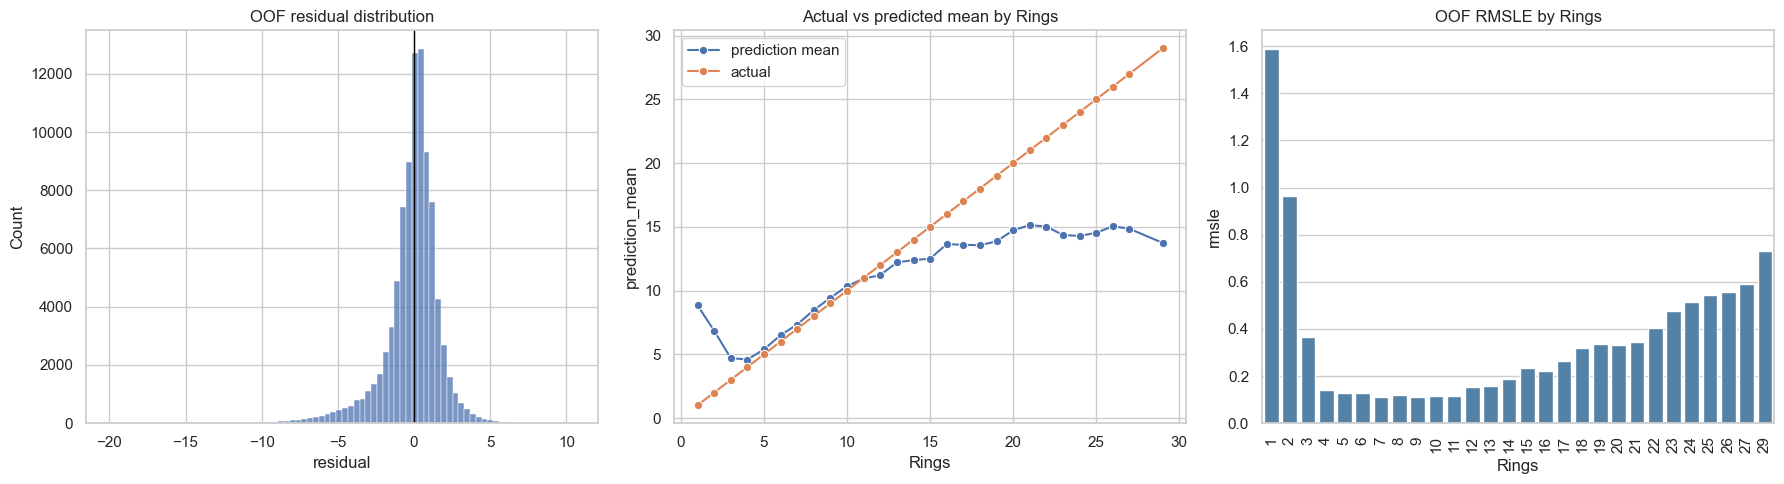

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(oof_df["residual"], bins=80, ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("OOF residual distribution")

sns.lineplot(data=oof_by_ring, x="Rings", y="prediction_mean", marker="o", label="prediction mean", ax=axes[1])
sns.lineplot(data=oof_by_ring, x="Rings", y="Rings", marker="o", label="actual", ax=axes[1])
axes[1].set_title("Actual vs predicted mean by Rings")

sns.barplot(data=oof_by_ring, x="Rings", y="rmsle", color="steelblue", ax=axes[2])
axes[2].set_title("OOF RMSLE by Rings")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## 8. Permutation Importance on a Holdout Split

CV 기준 best model을 한 번 더 holdout split에 학습시킨 뒤, permutation importance로 baseline 수준의 feature 영향도를 확인합니다. 이 값은 모델 해석의 절대값이라기보다 다음 feature engineering 후보를 정하는 참고용입니다.


Holdout RMSLE for importance model: 0.150491


,feature,importance_mean,importance_std
0,Shell_weight,0.116406,0.001578
1,Shell_to_shucked,0.019437,0.000278
2,Height,0.018348,0.000116
3,Shucked_ratio,0.009211,0.000203
4,Length,0.005047,0.000233
5,Sex_I,0.004384,0.000159
6,Whole_weight,0.004201,0.000118
7,Diameter,0.001581,0.000035
8,Viscera_weight,0.001280,0.000019
9,Viscera_ratio,0.001228,0.000243


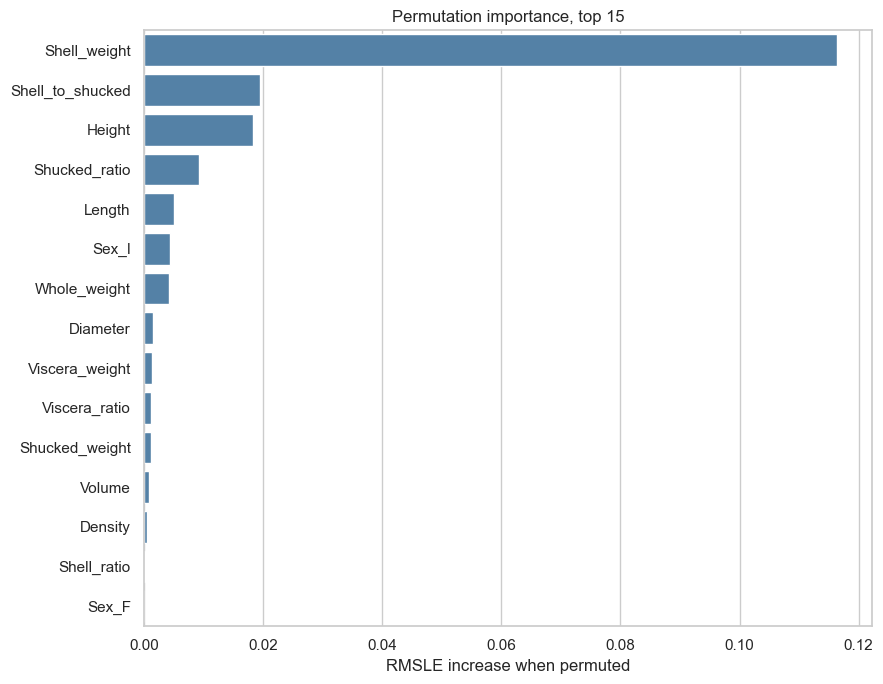

In [10]:
train_idx, valid_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bins,
)

best_estimator = clone(models[best_model_name])
best_estimator.fit(X.iloc[train_idx], y.iloc[train_idx])
holdout_pred = np.clip(best_estimator.predict(X.iloc[valid_idx]), 0, None)
holdout_rmsle = rmsle(y.iloc[valid_idx], holdout_pred)

importance_sample_size = min(12_000, len(valid_idx))
rng = np.random.default_rng(RANDOM_STATE)
importance_idx = rng.choice(valid_idx, size=importance_sample_size, replace=False)

importance = permutation_importance(
    best_estimator,
    X.iloc[importance_idx],
    y.iloc[importance_idx],
    scoring=lambda estimator, X_valid, y_valid: -rmsle(y_valid, estimator.predict(X_valid)),
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print(f"Holdout RMSLE for importance model: {holdout_rmsle:.6f}")
display(importance_df)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance_df.head(15), y="feature", x="importance_mean", ax=ax, color="steelblue")
ax.set_title("Permutation importance, top 15")
ax.set_xlabel("RMSLE increase when permuted")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 9. Baseline Findings and Next Steps

- `Dummy_median`은 실제 모델 개선폭을 비교하기 위한 하한선입니다.
- 선형 모델은 빠르고 안정적이지만, 비선형 트리 모델이 더 좋은 RMSLE를 보이는지 확인합니다.
- `log1p(Rings)` 타깃 변환이 유리하면 다음 모델링에서도 우선 비교 대상으로 둡니다.
- 다음 노트북(`04_modeling.ipynb`)에서는 best baseline을 기준으로 feature v2, 이상치 처리, 모델 튜닝을 실험합니다.
- 최종 제출 파일 생성은 별도 `05_submission.ipynb`에서 수행합니다.
